## 7.2 K-means應用：信用卡客戶分群

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
folder="/content/drive/MyDrive/資料科學自學聖經/ch07"

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

df = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch07/customer.csv')
dict1 = {'男':1, '女':2}
df['性別'].replace(dict1, inplace=True)
df

,性別,年齡,收入(千),消費指數(1-100)
0,1,34,78,1
1,1,20,61,49
2,1,29,28,82
3,2,31,81,93
4,1,48,60,49
...,...,...,...,...
195,2,33,86,95
196,1,35,28,61
197,2,68,48,48
198,1,38,71,75


進行分群

In [13]:
km = KMeans(n_clusters=5)
km.fit(df)
km.labels_

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([1, 0, 2, 3, 0, 4, 0, 1, 4, 3, 3, 2, 0, 0, 1, 0, 0, 4, 1, 0, 1, 3,
       1, 0, 1, 4, 0, 2, 0, 4, 2, 0, 1, 1, 1, 0, 3, 3, 0, 0, 1, 0, 3, 0,
       0, 3, 4, 0, 0, 0, 0, 3, 0, 0, 4, 0, 0, 1, 3, 0, 1, 2, 2, 2, 3, 3,
       2, 3, 4, 1, 1, 3, 0, 4, 0, 2, 3, 1, 0, 0, 1, 0, 0, 1, 1, 3, 0, 0,
       0, 0, 0, 0, 3, 3, 0, 0, 1, 3, 1, 0, 0, 2, 2, 4, 0, 1, 4, 2, 0, 0,
       0, 3, 3, 3, 0, 0, 4, 3, 3, 0, 1, 3, 0, 0, 0, 0, 4, 1, 3, 2, 2, 0,
       0, 0, 0, 0, 1, 4, 0, 1, 2, 2, 3, 0, 1, 2, 2, 2, 0, 1, 0, 1, 3, 3,
       4, 0, 3, 0, 0, 0, 3, 0, 1, 0, 4, 1, 2, 0, 0, 0, 0, 0, 3, 0, 0, 3,
       4, 3, 4, 0, 0, 4, 4, 1, 2, 4, 1, 3, 2, 1, 1, 4, 3, 1, 4, 3, 2, 0,
       3, 3], dtype=int32)

增加新欄位:「類別」

In [14]:
df['類別'] = km.labels_
df.head(10)

,性別,年齡,收入(千),消費指數(1-100),類別
0,1,34,78,1,1
1,1,20,61,49,0
2,1,29,28,82,2
3,2,31,81,93,3
4,1,48,60,49,0
5,2,42,34,17,4
6,1,26,54,54,0
7,1,43,78,17,1
8,1,48,39,36,4
9,2,32,103,69,3


列出「類別」為0的前30筆資料

In [8]:
df2 = df[df['類別']==0]
df3 = df2.iloc[0:30, :]
df3

,性別,年齡,收入(千),消費指數(1-100),類別
4,1,48,60,49,0
8,1,48,39,36,0
12,1,59,54,47,0
15,1,68,63,43,0
16,1,57,54,51,0
19,2,51,67,43,0
23,1,49,62,56,0
26,1,53,46,46,0
43,2,60,50,49,0
47,2,50,43,45,0


列出「類別」為1的前30筆資料

In [11]:
df2 = df[df['類別']==1]
df3 = df2.iloc[0:30, :]
df3

,性別,年齡,收入(千),消費指數(1-100),類別
3,2,31,81,93,1
9,2,32,103,69,1
10,2,29,98,88,1
21,1,32,126,74,1
36,1,28,77,97,1
37,1,32,73,73,1
42,1,39,78,88,1
45,1,30,137,83,1
51,1,28,87,75,1
58,1,40,71,95,1


列出「類別」為5的前30筆資料

In [10]:
df2 = df[df['類別']==5]
df3 = df2.iloc[0:30, :]
df3

,性別,年齡,收入(千),消費指數(1-100),類別
5,2,42,34,17,5
17,2,58,20,15,5
25,2,20,16,6,5
29,1,19,15,39,5
46,2,36,37,26,5
54,1,64,19,3,5
68,1,67,19,14,5
73,2,46,25,5,5
103,1,37,20,13,5
106,2,40,29,31,5


In [20]:
km = KMeans(n_clusters=4)
km.fit(df)
km.labels_

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([3, 1, 0, 2, 1, 1, 1, 3, 1, 2, 2, 0, 1, 1, 3, 1, 1, 1, 3, 1, 3, 2,
       3, 1, 3, 1, 1, 0, 1, 0, 0, 1, 3, 3, 3, 1, 2, 2, 1, 1, 3, 1, 2, 1,
       1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 2, 1, 3, 0, 0, 0, 2, 2,
       0, 2, 1, 3, 3, 2, 0, 1, 1, 0, 2, 3, 0, 1, 3, 1, 1, 3, 3, 2, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 3, 2, 3, 1, 1, 0, 0, 1, 1, 3, 1, 0, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 3, 2, 1, 1, 1, 1, 1, 3, 2, 0, 0, 1,
       1, 1, 1, 1, 3, 1, 1, 3, 0, 0, 2, 3, 3, 0, 0, 0, 1, 3, 1, 3, 2, 2,
       1, 1, 2, 1, 3, 1, 2, 1, 3, 1, 1, 3, 0, 1, 1, 1, 1, 1, 2, 1, 1, 2,
       1, 2, 1, 1, 0, 1, 1, 3, 0, 1, 3, 2, 0, 3, 3, 1, 2, 3, 1, 2, 0, 1,
       2, 2], dtype=int32)

評估 K-Means 分群效果

In [28]:
for n in range(2,8):
  km = KMeans(n_clusters=n)
  km.fit(df)
  metric = calinski_harabasz_score(df, km.labels_)
  print('群組數量：{}，評分：{}'.format(n, metric))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


群組數量：2，評分：89.12565051650722
群組數量：3，評分：113.5036295243098
群組數量：4，評分：127.65185810628219
群組數量：5，評分：151.22019346132433
群組數量：6，評分：166.7799094282953


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


群組數量：7，評分：162.26586753830253


## 7.3 DBSCAN應用：信用卡客戶分群

##使用字典對照法,將性別欄位的文字轉為數值資料

In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch07/customer.csv')
dict1 = {'男':1, '女':2}
df['性別'].replace(dict1, inplace=True)
df

,性別,年齡,收入(千),消費指數(1-100)
0,1,34,78,1
1,1,20,61,49
2,1,29,28,82
3,2,31,81,93
4,1,48,60,49
...,...,...,...,...
195,2,33,86,95
196,1,35,28,61
197,2,68,48,48
198,1,38,71,75


## 標準化與設定密度半徑,最小資料筆數

In [47]:
scaler = StandardScaler()
scaler.fit(df)
dfScaled = scaler.transform(df)
dbscan = DBSCAN(eps=0.9, min_samples=2)
dbs = dbscan.fit(dfScaled)
dbs.labels_

array([ 0,  0,  1,  2,  3,  4,  0,  0,  5,  2,  2,  6,  3,  7,  8,  9,  3,
        4,  0, 10,  8, 11,  8,  3,  8, -1,  3, 12,  0, -1,  1,  7,  0,  0,
        0,  0,  0,  0,  7,  7,  8,  0, 13, 14,  0, 11,  4, 10, 10,  3,  7,
        0, 14, 10, 15,  7,  3,  0, 13, 10,  0,  6,  6, 12,  2,  2, 12,  2,
       15, -1,  8,  0,  0,  4,  8, 16,  2,  8,  0, 10, 14,  0, 10,  0,  0,
        0,  7, 10,  9,  8,  8, 10,  2,  0, 10,  7,  7,  2,  8,  8,  3, 16,
        6, 17,  7,  0,  4,  1,  0,  9, 10, 13,  2, 13,  3,  3,  4,  0,  2,
       10, -1,  2, 10,  3,  7, 14,  4,  0,  2,  1,  1,  3, 10, 10,  3, 10,
        0,  4,  0,  8, 12,  6,  0,  8,  8, 16, 12,  6,  8,  8,  3,  8,  2,
        2,  4,  7,  2, 10,  0, 14,  2, 14,  0,  7, 15,  0,  6,  0,  3,  7,
        7,  7,  2, 10,  9,  2,  4,  0,  5,  7,  0, 17, 15,  8,  6,  4,  0,
       13,  7,  0,  8,  4,  2,  8, 14,  2,  0, 14,  0, 13])

##將分組結果,加入原始資料集

In [31]:
df['類別'] = dbs.labels_
df.head(20)

,性別,年齡,收入(千),消費指數(1-100),類別
0,1,34,78,1,-1
1,1,20,61,49,0
2,1,29,28,82,7
3,2,31,81,93,1
4,1,48,60,49,2
5,2,42,34,17,-1
6,1,26,54,54,0
7,1,43,78,17,-1
8,1,48,39,36,-1
9,2,32,103,69,-1


##檢視分群結果

In [32]:
df2 = df[df['類別']==0]
df3 = df2.iloc[0:30, :]
df3

,性別,年齡,收入(千),消費指數(1-100),類別
1,1,20,61,49,0
6,1,26,54,54,0
28,1,26,62,55,0
35,1,18,59,41,0
44,1,24,60,52,0
138,1,19,64,46,0
167,1,27,67,56,0


##檢視分群結果

In [33]:
df2 = df[df['類別']==4]
df3 = df2.iloc[0:30, :]
df3

,性別,年齡,收入(千),消費指數(1-100),類別
42,1,39,78,88,4
58,1,40,71,95,4
111,1,34,78,90,4
113,1,39,69,91,4
187,1,36,87,92,4
199,1,32,75,93,4


## 找出異常值

In [45]:
df2 = df[df['類別']==-1]
df3 = df2.iloc[0:30, :]
df3

,性別,年齡,收入(千),消費指數(1-100),類別
0,1,34,78,1,-1
5,2,42,34,17,-1
7,1,43,78,17,-1
8,1,48,39,36,-1
9,2,32,103,69,-1
11,2,21,33,81,-1
14,2,47,78,16,-1
17,2,58,20,15,-1
18,1,42,86,20,-1
20,2,45,126,28,-1


## PCA

In [48]:
from sklearn.decomposition import PCA

In [49]:
pca = PCA(n_components=0.95)
data = pca.fit_transform([[2,8,4,5,9,3], [6,3,0,8,7,1],
                          [5,4,9,1,8,2]])
print(data)

[[-0.27506139  4.0732061 ]
 [ 5.92362693 -1.89137796]
 [-5.64856554 -2.18182813]]


In [ ]:
import pandas as pd
prior = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch07/order_products__prior.csv')
products = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch07/products.csv')
orders = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch07/orders.csv')
aisles = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch07/aisles.csv')
t1 = pd.merge(prior, products, on=['product_id',
                                   'product_id'])
t1 = pd.merge(t1, orders, on=['order_id', 'order_id'])
mt = pd.merge(t1, aisles, on=['aisle_id', 'aisle_id'])
print(mt.shape)
mt

In [ ]:
cross = pd.crosstab(mt['user_id'], mt['aisle'])
print(cross.shape)
cross

NameError: ignored

In [ ]:
pca = PCA(n_components=0.95)
# pca = PCA(n_components=0.9)
data = pca.fit_transform(cross)
print(data.shape)

In [ ]:
# 下載翰字鑄造-台北黑體
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

--2023-04-25 07:13:28--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 173.194.195.100, 173.194.195.101, 173.194.195.113, ...
Connecting to drive.google.com (drive.google.com)|173.194.195.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/cmmptddl7f2srod5delgufequ6vaiptb/1682406750000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=c25b1a39-64d8-4e3c-84b3-db71d82b109e [following]
--2023-04-25 07:13:28--  https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/cmmptddl7f2srod5delgufequ6vaiptb/1682406750000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=c25b1a39-64d8-4e3c-84b3-db71d82b109e
Resolving doc-0k-9o-docs.googleusercontent.com (doc-0k-9o-docs.googleusercontent.com)... 142.251.161.132, 2607:f8b0:4001:c5c::84
Connecting to d

In [ ]:
# 下載Google-思源正黑體
!wget --content-disposition https://fonts.google.com/download?family=Noto%20Sans%20TC
!unzip 'Noto_Sans_TC.zip'  #解壓縮到主機目錄

--2023-04-25 07:15:02--  https://fonts.google.com/download?family=Noto%20Sans%20TC
Resolving fonts.google.com (fonts.google.com)... 74.125.132.113, 74.125.132.138, 74.125.132.139, ...
Connecting to fonts.google.com (fonts.google.com)|74.125.132.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘Noto_Sans_TC.zip’

Noto_Sans_TC.zip        [  <=>               ]  28.42M   125MB/s    in 0.2s    

2023-04-25 07:15:04 (125 MB/s) - ‘Noto_Sans_TC.zip’ saved [29796344]

Archive:  Noto_Sans_TC.zip
replace OFL.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: OFL.txt                 
replace NotoSansTC-Thin.otf? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: NotoSansTC-Thin.otf     
replace NotoSansTC-Light.otf? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: NotoSansTC-Light.otf    
replace NotoSansTC-Regular.otf? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: NotoSansTC-Regular.otf  
replace NotoSansTC

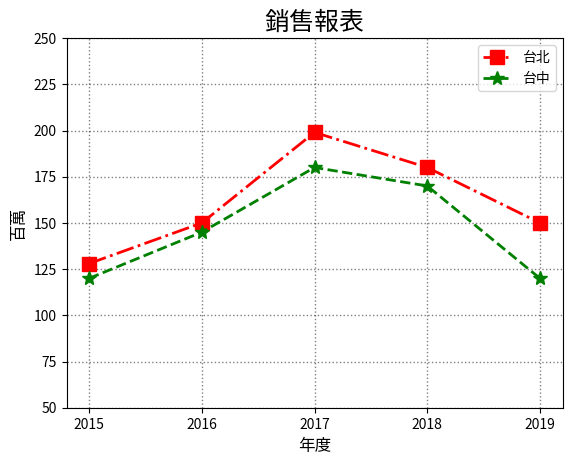

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
# 加入中文字型設定：翰字鑄造-台北黑體
fontManager.addfont('NotoSansTC-Regular.otf')
matplotlib.rc('font', family='Taipei Sans TC Beta')
#matplotlib.rc('font', family='Noto_Sans_TC')
year = [2015,2016,2017,2018,2019]
city1 = [128,150,199,180,150]
plt.plot(year, city1, 'r-.s', lw=2, ms=10, label="台北")
city2 = [120,145,180,170,120]
plt.plot(year, city2, 'g--*', lw=2, ms=10, label="台中")
plt.legend()
plt.ylim(50, 250)
plt.xticks(year)
plt.title("銷售報表", fontsize=18)
plt.xlabel("年度", fontsize=12)
plt.ylabel("百萬", fontsize=12)
plt.grid(color='k', ls=':', lw=1, alpha=0.5)
plt.show()